In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [2]:
# only run when using nltk first time
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\piyussss\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\piyussss\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df= pd.read_csv("Task_dataset.csv")
df.head()

,id,created,description,key,priority,project,project_name,repositoryname,resolution,resolved,status,title,type,updated,votes,watchers,assignee_id,reporter_id
0,542286,2010-07-02 06:45:40.191,Looks like Google collections has types that a...,JACKSON-317,Major,JACKSON,Jackson JSON Processor,CODEHAUS,Fixed,2010-12-16 11:36:37.031,Closed,Add support for Guava (FKA google collections)...,Improvement,2011-10-31 01:13:18.078,1,2,22976.0,22976.0
1,223988,2012-01-05 02:23:04.607,dpkg -i hadoop_1.0.0-1_amd64.deb on a 32bit sq...,HADOOP-7954,Minor,HADOOP,Hadoop Common,ASF,NaN,NaN,Open,Debian Squeeze install of hadoop 1.0.0 .deb : ...,Bug,2012-01-05 02:23:04.607,0,2,NaN,17494.0
2,459798,2010-09-09 00:24:08,NaN,RFPL-802,Critical,RFPL,RichFaces Planning,JBOSS,Done,2010-09-28 22:00:03,Resolved,Update hudson builds based on up new build setup,Task,2010-09-28 22:00:03,0,0,73878.0,73878.0
3,31130,2007-02-27 16:12:06.215,The problem occurs on the select tag when mult...,WW-1772,Major,WW,Struts 2,ASF,Fixed,2007-03-16 00:18:01.424,Closed,Select tag breaks when multiple=true,Bug,2012-10-29 06:11:32.622,0,0,NaN,14701.0
4,425457,2012-07-05 21:24:27,"""Document models can be created that have nest...",TEIIDDES-1436,Major,TEIIDDES,Teiid Designer,JBOSS,Done,2013-06-25 11:13:17,Closed,Hand Generated XML Document Models do not Corr...,Bug,2013-12-09 22:34:37,0,2,75980.0,75980.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              8000 non-null   int64  
 1   created         8000 non-null   object 
 2   description     7255 non-null   object 
 3   key             8000 non-null   object 
 4   priority        7864 non-null   object 
 5   project         8000 non-null   object 
 6   project_name    8000 non-null   object 
 7   repositoryname  8000 non-null   object 
 8   resolution      6750 non-null   object 
 9   resolved        6750 non-null   object 
 10  status          8000 non-null   object 
 11  title           8000 non-null   object 
 12  type            8000 non-null   object 
 13  updated         8000 non-null   object 
 14  votes           8000 non-null   int64  
 15  watchers        8000 non-null   int64  
 16  assignee_id     5976 non-null   float64
 17  reporter_id     7993 non-null   f

In [5]:
print(df.columns)

Index(['id', 'created', 'description', 'key', 'priority', 'project',
       'project_name', 'repositoryname', 'resolution', 'resolved', 'status',
       'title', 'type', 'updated', 'votes', 'watchers', 'assignee_id',
       'reporter_id'],
      dtype='object')


In [6]:
type_counts = df['type'].value_counts()

rare_types = type_counts[type_counts < 30].index

df['type'] = df['type'].replace(rare_types, 'Other')

In [7]:
df['type'].value_counts()

type
Bug                4281
Improvement        1484
Task                706
New Feature         465
Sub-task            445
Feature Request     340
Other               100
Enhancement          87
Wish                 56
Test                 36
Name: count, dtype: int64

In [8]:
# priority distribution by type
pd.crosstab(df['type'], df['priority'])

priority,Blocker,Critical,Major,Minor,Optional,Trivial
type,,,,,,
Bug,221,288,2767,791,7,109
Enhancement,4,4,64,12,2,1
Feature Request,6,15,265,40,13,1
Improvement,8,22,829,534,0,84
New Feature,4,7,324,118,0,10
Other,2,4,65,23,1,4
Sub-task,5,21,372,39,0,8
Task,24,24,488,119,7,24
Test,2,2,21,10,0,1


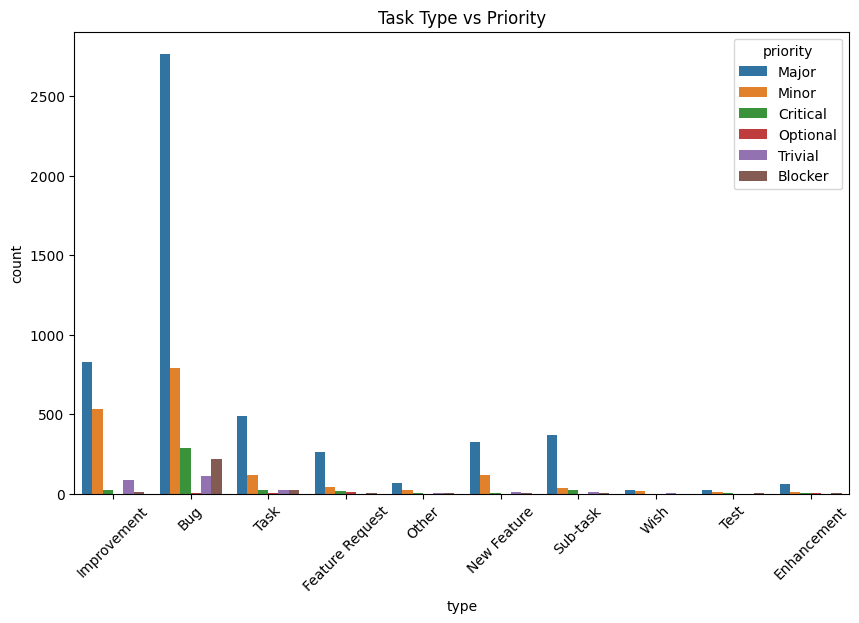

In [9]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='type', hue='priority')
plt.xticks(rotation=45)
plt.title("Task Type vs Priority")
plt.show()

# all the types are mostly major so it will make the model bias so not using this feature also

In [10]:
df['votes'].value_counts().head(10)

# most of the votes are 0 so this is not important feature

votes
0     7455
1      334
2       84
3       42
4       22
5       11
6       11
7       10
8        5
12       4
Name: count, dtype: int64

In [11]:
df = df[['title','description','priority']]

In [12]:
df.head()

,title,description,priority
0,Add support for Guava (FKA google collections)...,Looks like Google collections has types that a...,Major
1,Debian Squeeze install of hadoop 1.0.0 .deb : ...,dpkg -i hadoop_1.0.0-1_amd64.deb on a 32bit sq...,Minor
2,Update hudson builds based on up new build setup,NaN,Critical
3,Select tag breaks when multiple=true,The problem occurs on the select tag when mult...,Major
4,Hand Generated XML Document Models do not Corr...,"""Document models can be created that have nest...",Major


In [13]:
df.isnull().sum()

title            0
description    745
priority       136
dtype: int64

In [14]:
df = df.dropna()

In [15]:
df['task_text'] = df['title'] + " " + df['description']
df[['task_text','priority']].head()

,task_text,priority
0,Add support for Guava (FKA google collections)...,Major
1,Debian Squeeze install of hadoop 1.0.0 .deb : ...,Minor
3,Select tag breaks when multiple=true The probl...,Major
4,Hand Generated XML Document Models do not Corr...,Major
5,tcp transport async sending could send message...,Major


In [16]:
df['priority'].value_counts()

priority
Major       4634
Minor       1610
Critical     364
Blocker      256
Trivial      228
Optional      29
Name: count, dtype: int64

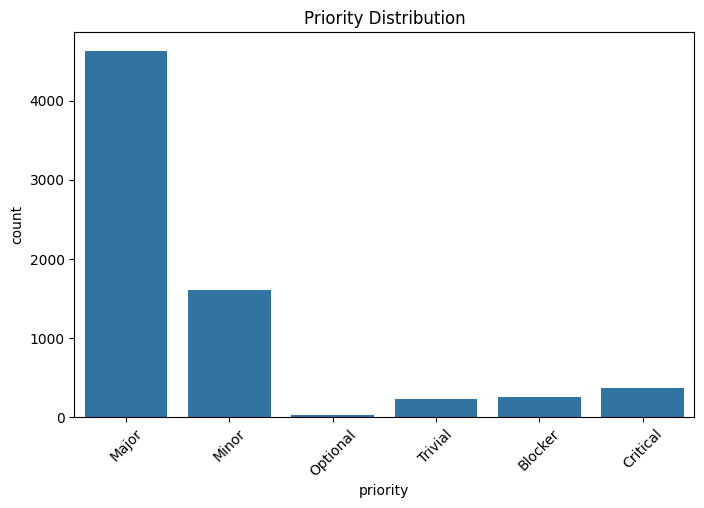

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x=df['priority'])
plt.title("Priority Distribution")
plt.xticks(rotation=45)
plt.show()

In [18]:
df['text_length'] = df['task_text'].apply(len)

df['text_length'].describe()

count      7121.000000
mean       1110.310069
std        6845.788492
min          11.000000
25%         232.000000
50%         432.000000
75%         897.000000
max      421671.000000
Name: text_length, dtype: float64

In [19]:
df = df[df['text_length'] < 8000]
df.describe()

,text_length
count,7020.000000
mean,769.751709
std,1033.472469
min,11.000000
25%,230.000000
50%,422.000000
75%,861.250000
max,7933.000000


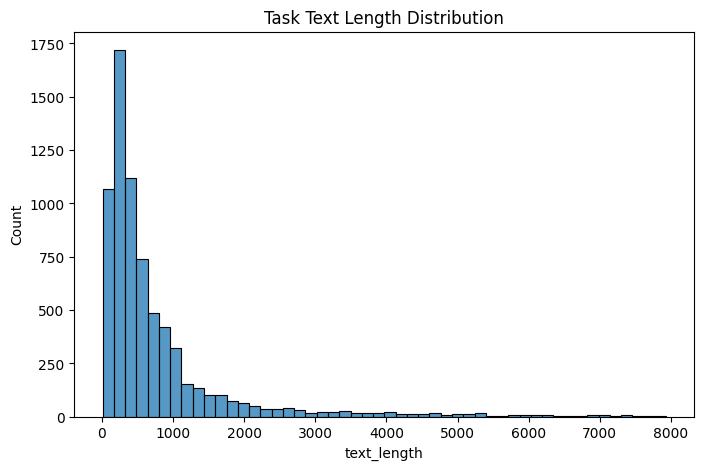

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50)
plt.title("Task Text Length Distribution")
plt.show()

In [21]:
df.head()

,title,description,priority,task_text,text_length
0,Add support for Guava (FKA google collections)...,Looks like Google collections has types that a...,Major,Add support for Guava (FKA google collections)...,349
1,Debian Squeeze install of hadoop 1.0.0 .deb : ...,dpkg -i hadoop_1.0.0-1_amd64.deb on a 32bit sq...,Minor,Debian Squeeze install of hadoop 1.0.0 .deb : ...,206
3,Select tag breaks when multiple=true,The problem occurs on the select tag when mult...,Major,Select tag breaks when multiple=true The probl...,458
4,Hand Generated XML Document Models do not Corr...,"""Document models can be created that have nest...",Major,Hand Generated XML Document Models do not Corr...,671
5,tcp transport async sending could send message...,Right now the tcp transport could send message...,Major,tcp transport async sending could send message...,541


In [22]:
df['task_text'].head()

0    Add support for Guava (FKA google collections)...
1    Debian Squeeze install of hadoop 1.0.0 .deb : ...
3    Select tag breaks when multiple=true The probl...
4    Hand Generated XML Document Models do not Corr...
5    tcp transport async sending could send message...
Name: task_text, dtype: object

NOW START NLP

In [23]:
import re
import dateparser
from datetime import datetime

In [24]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\piyussss\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\piyussss\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [25]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    tokens = word_tokenize(text)

    tokens = [w for w in tokens if w not in stop_words]

    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return " ".join(tokens)

In [26]:
df['clean_text'] = df['task_text'].apply(clean_text)

In [27]:
df.head()

,title,description,priority,task_text,text_length,clean_text
0,Add support for Guava (FKA google collections)...,Looks like Google collections has types that a...,Major,Add support for Guava (FKA google collections)...,349,add support guava fka google collection starti...
1,Debian Squeeze install of hadoop 1.0.0 .deb : ...,dpkg -i hadoop_1.0.0-1_amd64.deb on a 32bit sq...,Minor,Debian Squeeze install of hadoop 1.0.0 .deb : ...,206,debian squeeze install hadoop 1 0 0 deb 64 bit...
3,Select tag breaks when multiple=true,The problem occurs on the select tag when mult...,Major,Select tag breaks when multiple=true The probl...,458,select tag break multiple true problem occurs ...
4,Hand Generated XML Document Models do not Corr...,"""Document models can be created that have nest...",Major,Hand Generated XML Document Models do not Corr...,671,hand generated xml document model correctly as...
5,tcp transport async sending could send message...,Right now the tcp transport could send message...,Major,tcp transport async sending could send message...,541,tcp transport async sending could send message...


In [28]:
priority_map = {
    'Blocker': 'High',
    'Critical': 'High',
    'Major': 'Medium',
    'Minor': 'Low',
    'Trivial': 'Low'
}

df['priority'] = df['priority'].map(priority_map)

df = df.dropna(subset=['priority'])

In [29]:
df['priority'].value_counts()

priority
Medium    4571
Low       1828
High       592
Name: count, dtype: int64

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

In [32]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df['clean_text'])

In [33]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df['priority'])

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (5592, 5000)
Testing samples: (1399, 5000)


In [36]:
import pickle

pickle.dump(tfidf, open("tfidf_vectorizer.pkl","wb"))
pickle.dump(label_encoder, open("label_encoder.pkl","wb"))

In [37]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score, classification_report

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.6540385989992852
              precision    recall  f1-score   support

           0       0.20      0.01      0.02       118
           1       0.49      0.06      0.11       366
           2       0.66      0.97      0.79       915

    accuracy                           0.65      1399
   macro avg       0.45      0.35      0.30      1399
weighted avg       0.58      0.65      0.54      1399



In [39]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [40]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.590421729807005
              precision    recall  f1-score   support

           0       0.19      0.05      0.08       118
           1       0.35      0.29      0.31       366
           2       0.67      0.78      0.72       915

    accuracy                           0.59      1399
   macro avg       0.40      0.37      0.37      1399
weighted avg       0.55      0.59      0.56      1399



In [42]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [43]:
svm_model.fit(X_train_balanced, y_train_balanced)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [45]:
y_pred_svm2 = svm_model.predict(X_test)

In [46]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm2))
print(classification_report(y_test, y_pred_svm2))

SVM Accuracy: 0.4960686204431737
              precision    recall  f1-score   support

           0       0.14      0.20      0.17       118
           1       0.33      0.41      0.36       366
           2       0.67      0.57      0.62       915

    accuracy                           0.50      1399
   macro avg       0.38      0.39      0.38      1399
weighted avg       0.54      0.50      0.51      1399

